In [1]:
import serial
import numpy as np
import time
import matplotlib.pyplot as plt
from IPython.display import clear_output, display

plt.style.use('dark_background')


In [3]:
with serial.Serial("COM4", 115200, rtscts=False) as ser:
    ser.write(b'hello\n')
    l = ser.readline().decode()
    print(l)


BOOT



In [8]:
cmd = '''
reset();
config(0, 110, 0, 5, 5, 5);
set_arr(1, 1, 50, 50, 50, 1);
run();

'''

cmd_str = "C:" + cmd + "?"
cmd_str

'C:\nreset();\nconfig(0, 110, 0, 5, 5, 5);\nset_arr(1, 1, 50, 50, 50, 1);\nrun();\n\n?'

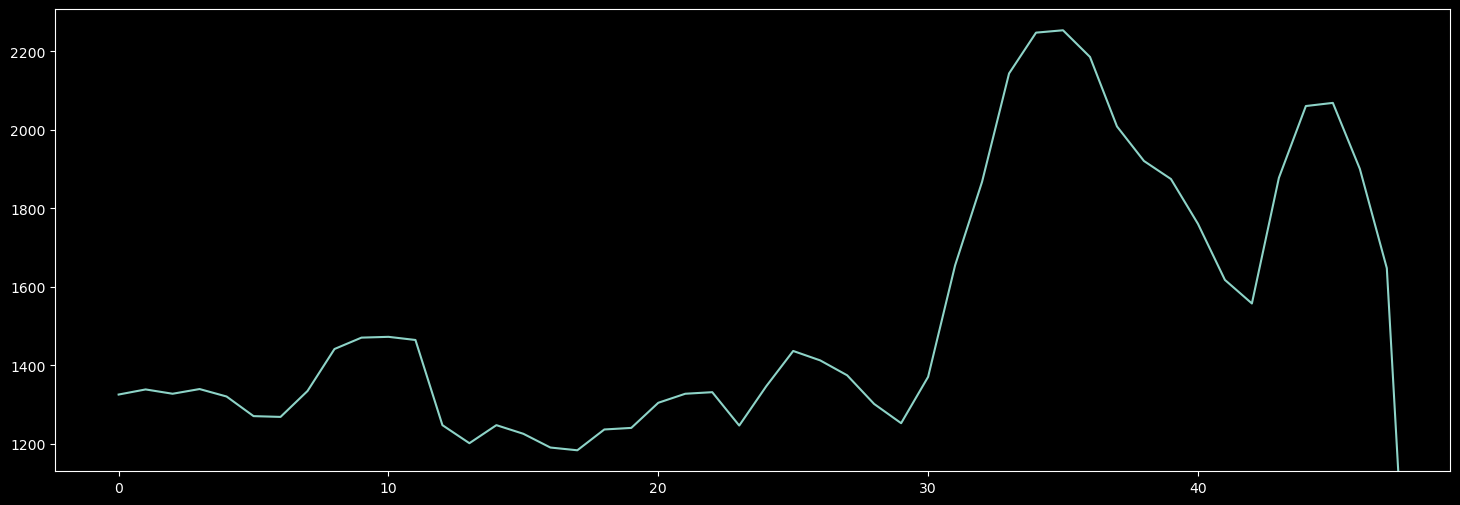

In [11]:
fig, ax = plt.subplots(1, 1, figsize = (18, 6))
line = ax.plot([])[0]
outputs = ""
with serial.Serial("COM4", 115200) as ser:
    start_timer = time.time()
    ser.write(cmd_str.encode())
    arr = []
    last_update_time,  last_update_length = 0, 0

    while (time.time() - start_timer < 1):
        if ser.in_waiting > 2:
            start_timer = time.time()
            l = ser.readline().decode().strip()
            if l[0] == '[':
                outputs += l + "\n"
            elif l[0].isdigit() and l[-1].isdigit():
                if l.count(',') == 3:
                    _arr = np.fromstring(l, sep = ',', dtype=int).tolist()
                    arr.append(_arr)
                else:
                    print(l)
            else:
                print(l)
        else:
            if (len(arr) - last_update_length > 1) and (time.time() - last_update_time > .01):
                plot_arr = np.array(arr)
                line.set_data(np.arange(plot_arr.shape[0]), plot_arr[:, 0])
                ax.autoscale_view(True, True) 
                ax.relim()
                
                last_update_length = len(arr)
                last_update_time = time.time()
                display(fig)
                clear_output(wait=True)

                plt.pause(0.0001)
            else:
                time.sleep(0.2)

                
plt.show()    

In [12]:
print(outputs)

[ 13880][V][u_adpd6100.cpp:584] preset_config_1(): [ADPD] Preset_config 1 set for timeslot:0. Two ambient channels. Total 6 bytes
[ 13882][V][u_adpd6100.cpp:631] preset_config_2(): [ADPD] Preset_config 2 set for timeslot:1. Total 8 bytes
[ 13891][I][PAM.cpp:37] detector_preset_1(): [PAM] Preset 1 set
[ 13896][V][do_c.cpp:83] detector_preset(): [DO_C] ADPD detector preset with current: 110
[ 13904][V][do_c.cpp:43] arr_set(): [DO_C] Set line 0 to type 1 with 50 x 50Hz samples, actinic:50, sub:1
[ 13913][V][PAM.cpp:74] run_preprocess(): [PAM] Run type:1, number:50, freq: 50, actinic: 50, subfactor 1
[ 13922][V][PAM.cpp:92] run_arr(): [PAM] Sample: 50, ref: 50, amb: 50, dark: 50
[ 13929][V][data_utils.cpp:10] dataclass(): [DATA_UTIL] DATACLASS Created
[ 13936][V][data_utils.cpp:10] dataclass(): [DATA_UTIL] DATACLASS Created
[ 13942][V][data_utils.cpp:10] dataclass(): [DATA_UTIL] DATACLASS Created
[ 13949][V][data_utils.cpp:10] dataclass(): [DATA_UTIL] DATACLASS Created
[ 13955][V][data_uti

In [116]:

def line_parse(l:str)->str:
    l = l.strip()
    if len(l) < 1:return ""
    if l[0] == '[':
        print(l)
        return ""
    else:
        return l.strip()

with serial.Serial("COM4", 115200, timeout = 5) as ser:

    ser.write("init,".encode())
    ts = time.time()
    while time.time() - ts < 1:
        if ser.in_waiting > 0:
            l = line_parse(ser.readline().decode())
            if l == "Wake!":
                ser.write("Ready".encode())
            if l == "2":
                ser.write("GO".encode())
                a1 = ser.read(4)
                a2 = ser.read(4)

            if l == "DONE":
                print(l)
                break
            else:
                print(l)

                

Wake!
2
DONE


In [120]:
(a1[0] << 24) + (a1[1] << 16) + (a1[2] << 8) + a1[3]

1234

In [119]:
a1

b'\x00\x00\x04\xd2'